In [5]:
import matplotlib
import matplotlib.pyplot as plt 
def plot(x, fname, num_inputs=3, num_interneurons=3):
    """
    Plot neural network data with flexible input and interneuron counts.
    
    Parameters:
    -----------
    x : array
        Data array with columns: [clock, output, inputs..., interneurons...]
    fname : str
        Filename for saving the plot
    num_inputs : int
        Number of input channels (3-6)
    num_interneurons : int
        Number of interneurons (3-6)
    """
    # Determine plotting window based on data length
    if len(x) > 605:
        clockVal = len(x) - 30
        skipVal = 0
        gWidth = 30
    else:
        clockVal = len(x) - 2
        skipVal = 0
        gWidth = 20
    
    # Calculate total number of subplots: 1 (inputs) + num_interneurons + 1 (output)
    num_subplots = 1 + num_interneurons + 1
    
    # Create figure with dynamic subplots
    fig, axes = plt.subplots(
        num_subplots, 1, sharex=False, sharey=False, figsize=(gWidth, 7)
    )
    
    # Extract time and output
    clock = x[:, 0][skipVal:clockVal]
    output = x[:, 1][skipVal:clockVal]
    
    # Extract input channels dynamically (columns 2 onwards)
    inputs = []
    for i in range(num_inputs):
        inputs.append(x[:, 2 + i][skipVal:clockVal])
    
    # Extract interneurons dynamically (after input columns)
    interneurons = []
    for i in range(num_interneurons):
        interneurons.append(x[:, 2 + num_inputs + i][skipVal:clockVal])
    
    # Styling parameters
    padVal = 0
    fSize = 20
    lwid = 3
    siz = 7
    
    # Plot inputs (all on first subplot)
    ax_input = axes[0]
    for inp in inputs:
        ax_input.plot(clock, inp, 'k.', linewidth=lwid, markersize=siz)
    ax_input.set_ylabel('Input', rotation=0, fontsize=fSize, labelpad=padVal)
    ax_input.spines['top'].set_visible(False)
    ax_input.spines['right'].set_visible(False)
    ax_input.spines['left'].set_visible(False)
    ax_input.get_yaxis().set_ticks([])
    ax_input.get_xaxis().set_ticks([])
    
    # Set y-axis limits for input plot
    miny = -94
    maxy = 3
    ax_input.set_ylim([miny, maxy])
    
    # Plot interneurons (one per subplot, in reverse order: N3, N2, N1)
    for i in range(num_interneurons):
        ax_neuron = axes[1 + i]
        neuron_label = f'N{num_interneurons - i}'
        
        ax_neuron.plot(clock, interneurons[i], 'm-')
        ax_neuron.set_ylabel(neuron_label, rotation=0, fontsize=fSize, labelpad=padVal)
        ax_neuron.spines['top'].set_visible(False)
        ax_neuron.spines['right'].set_visible(False)
        ax_neuron.spines['left'].set_visible(False)
        ax_neuron.spines['bottom'].set_visible(False)
        ax_neuron.get_yaxis().set_ticks([])
        ax_neuron.get_xaxis().set_ticks([])
    
    # Plot output (last subplot)
    ax_output = axes[-1]
    ax_output.plot(clock, output, 'g-')
    ax_output.set_ylabel('Output', rotation=0, fontsize=fSize, labelpad=padVal)
    ax_output.set_xlabel('Time [ms]', fontsize=fSize)
    ax_output.spines['top'].set_visible(False)
    ax_output.spines['right'].set_visible(False)
    ax_output.spines['left'].set_visible(False)
    ax_output.get_yaxis().set_ticks([])
    ax_output.set_xticks(np.arange(0, len(clock) + 1, 100))
    
    # Set tick label sizes
    matplotlib.rc('xtick', labelsize=18)
    matplotlib.rc('ytick', labelsize=18)
    
    # Save and display
    plt.savefig(fname + '.png', bbox_inches='tight', dpi=120)
    plt.show()
    plt.close()
    
    return


# Example usage:
# For 3 inputs (A, B, C) and 3 interneurons (N3, N2, N1):
# plot(x, fname, num_inputs=3, num_interneurons=3)

# For 4 inputs (A, B, C, D) and 4 interneurons (N4, N3, N2, N1):
# plot(x, fname, num_inputs=4, num_interneurons=4)

# For 6 inputs and 6 interneurons:
# plot(x, fname, num_inputs=6, num_interneurons=6)

In the Directory: /Users/my19aac/Desktop/Evosnn2/6_loops_test
Processing: network_activity_Top_6_no_N6_loop_FABCDEFFBCDEFFCDEFFDEF.txt


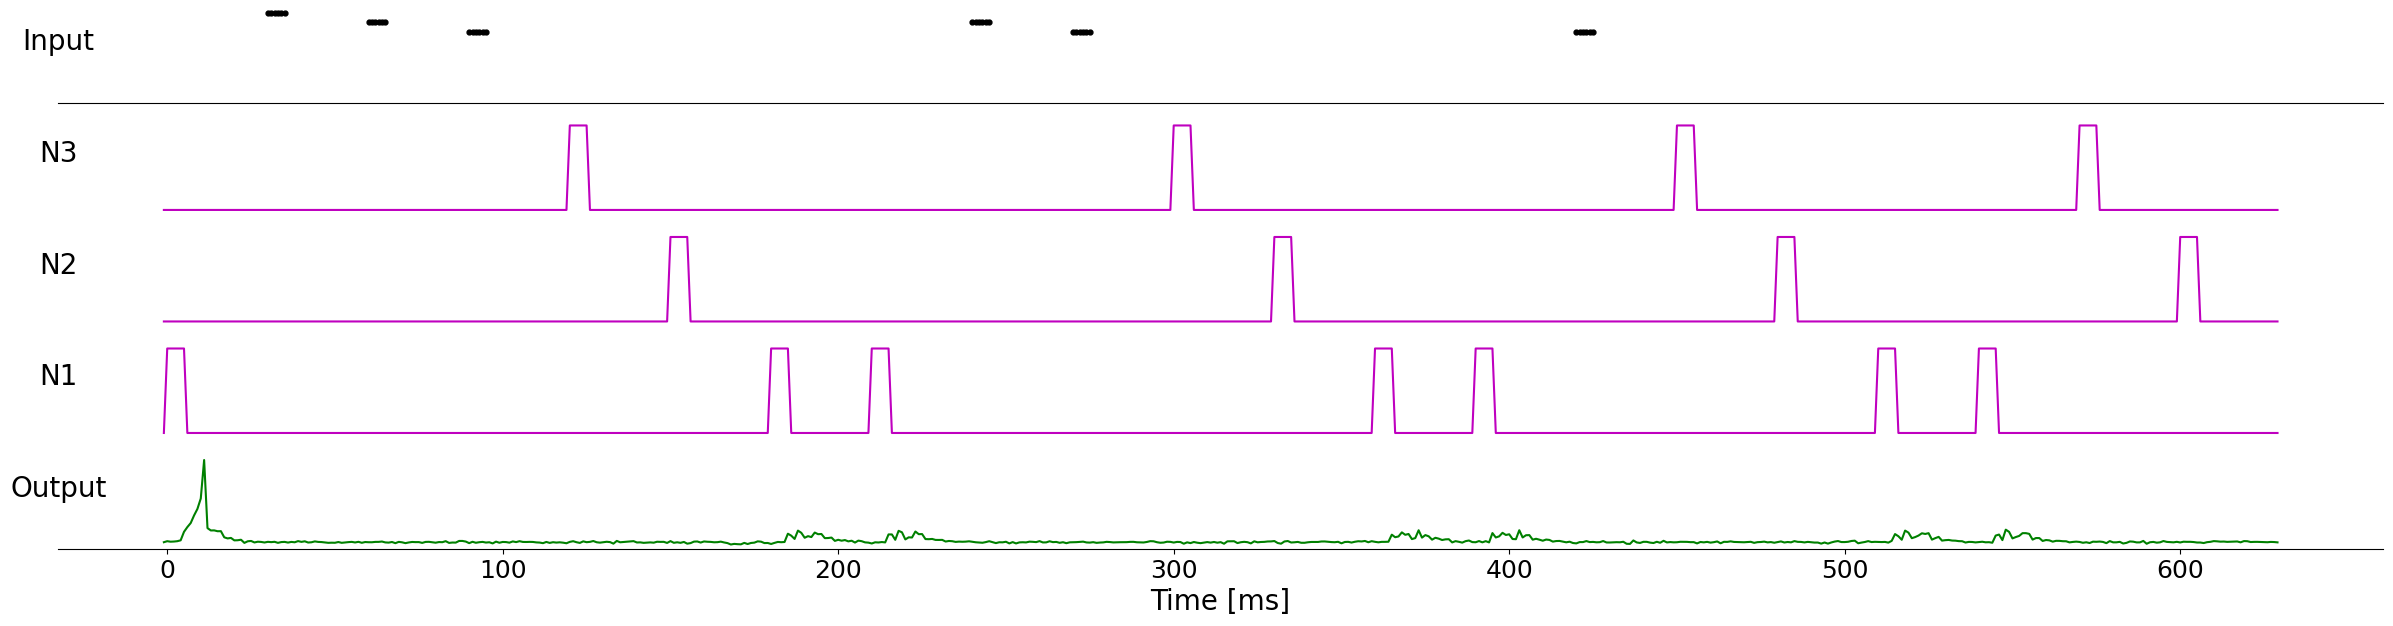

Successfully plotted: network_activity_Top_6_no_N6_loop_FABCDEFFBCDEFFCDEFFDEF.txt


In [6]:
import os

rootDir = os.getcwd()
fileList = os.listdir(rootDir)

print(f"In the Directory: {rootDir}")
for fname in fileList:
    if os.path.isfile(fname) and fname.startswith('network_activity_T') and (fname.endswith('.txt') or fname.endswith('.dat')):
        try:
            print(f"Processing: {fname}")
            x = np.loadtxt(fname, 'float')
            plot(x, fname, num_inputs=3, num_interneurons=3)
            print(f"Successfully plotted: {fname}")
        except Exception as e:
            print(f"Error processing {fname}: {e}")

# Example usage for individual files:
# fname = 'network_activity_Top_3_5_splitloops_evo_AAAABBBBBABCABCABCCCCAAA.txt'
# x = np.loadtxt(fname, 'float')
# plot(x, fname, num_inputs=3, num_interneurons=5)

In the Directory: /Users/my19aac/Desktop/Evosnn2/6_loops_test
Processing: network_activity_Top_6_FBCDEFFBCDEFFBCDEF.txt


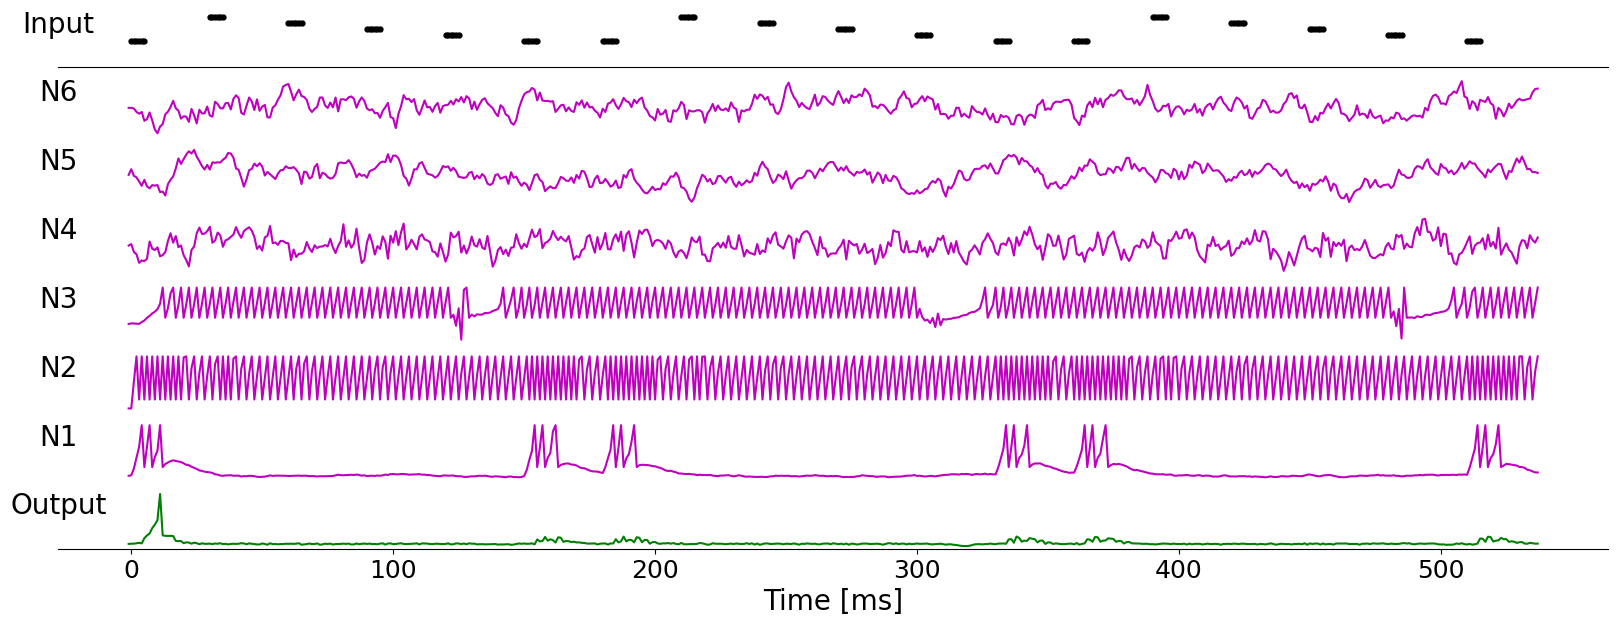

Successfully plotted: network_activity_Top_6_FBCDEFFBCDEFFBCDEF.txt
Processing: network_activity_Top_6_no_N6_loop_FABCDEFFABCDEFFBCDEFFACDEFFBCDEFFCDEF.txt


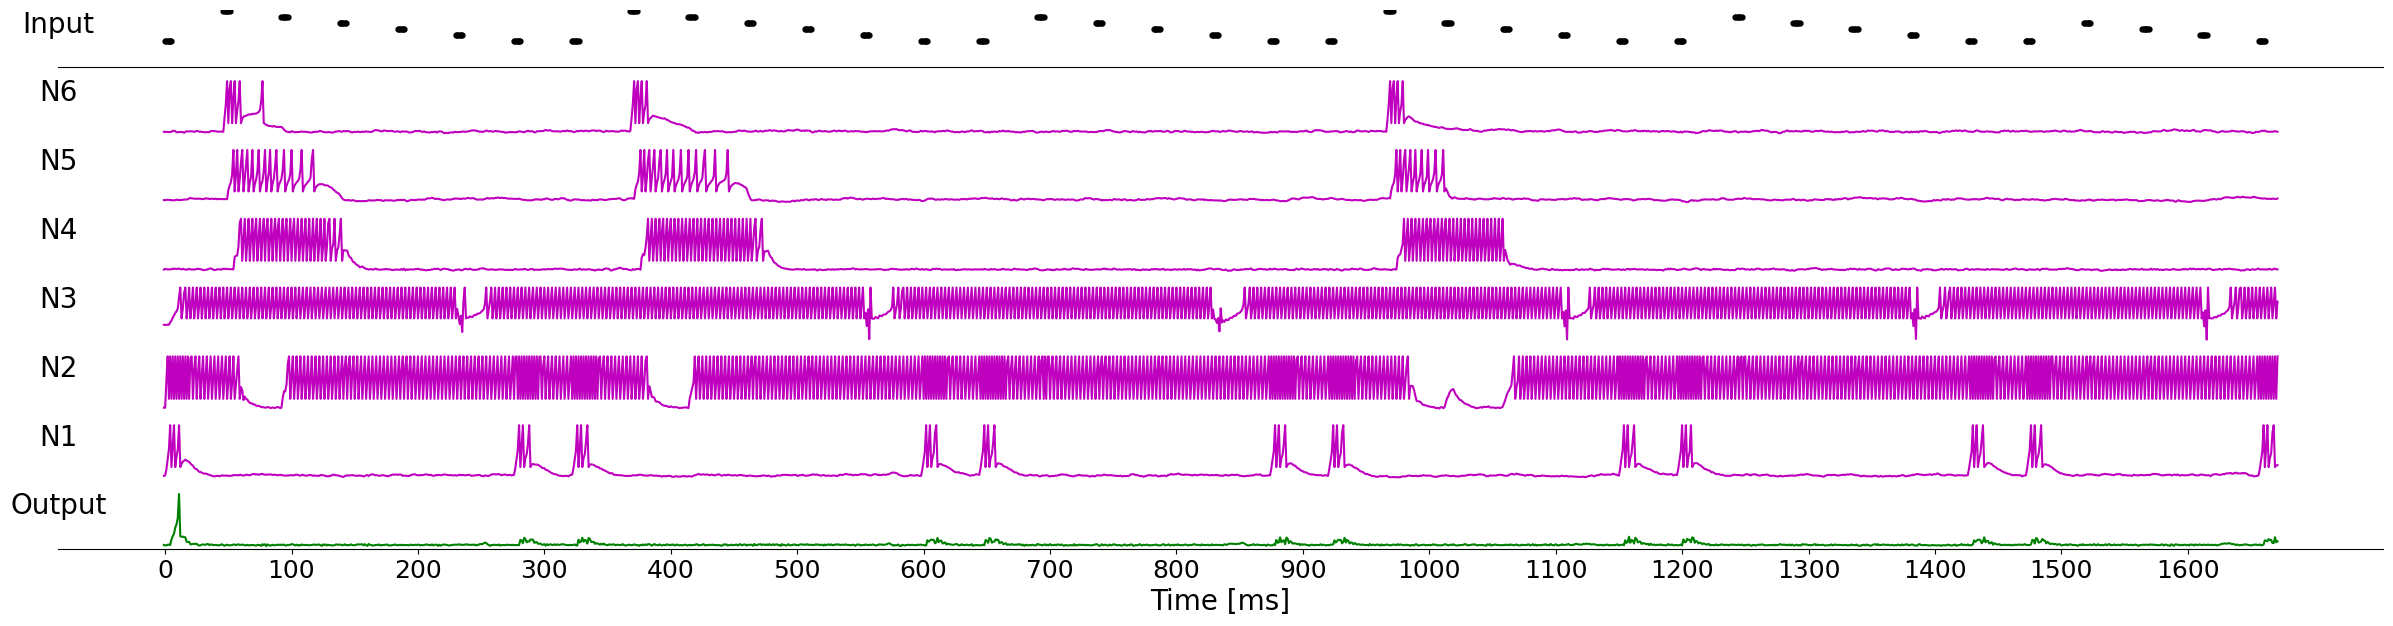

Successfully plotted: network_activity_Top_6_no_N6_loop_FABCDEFFABCDEFFBCDEFFACDEFFBCDEFFCDEF.txt
Processing: network_activity_Top_6_FABCDEFFABCDEFFBCDEFFACDEFFBCDEFFCDEF.txt


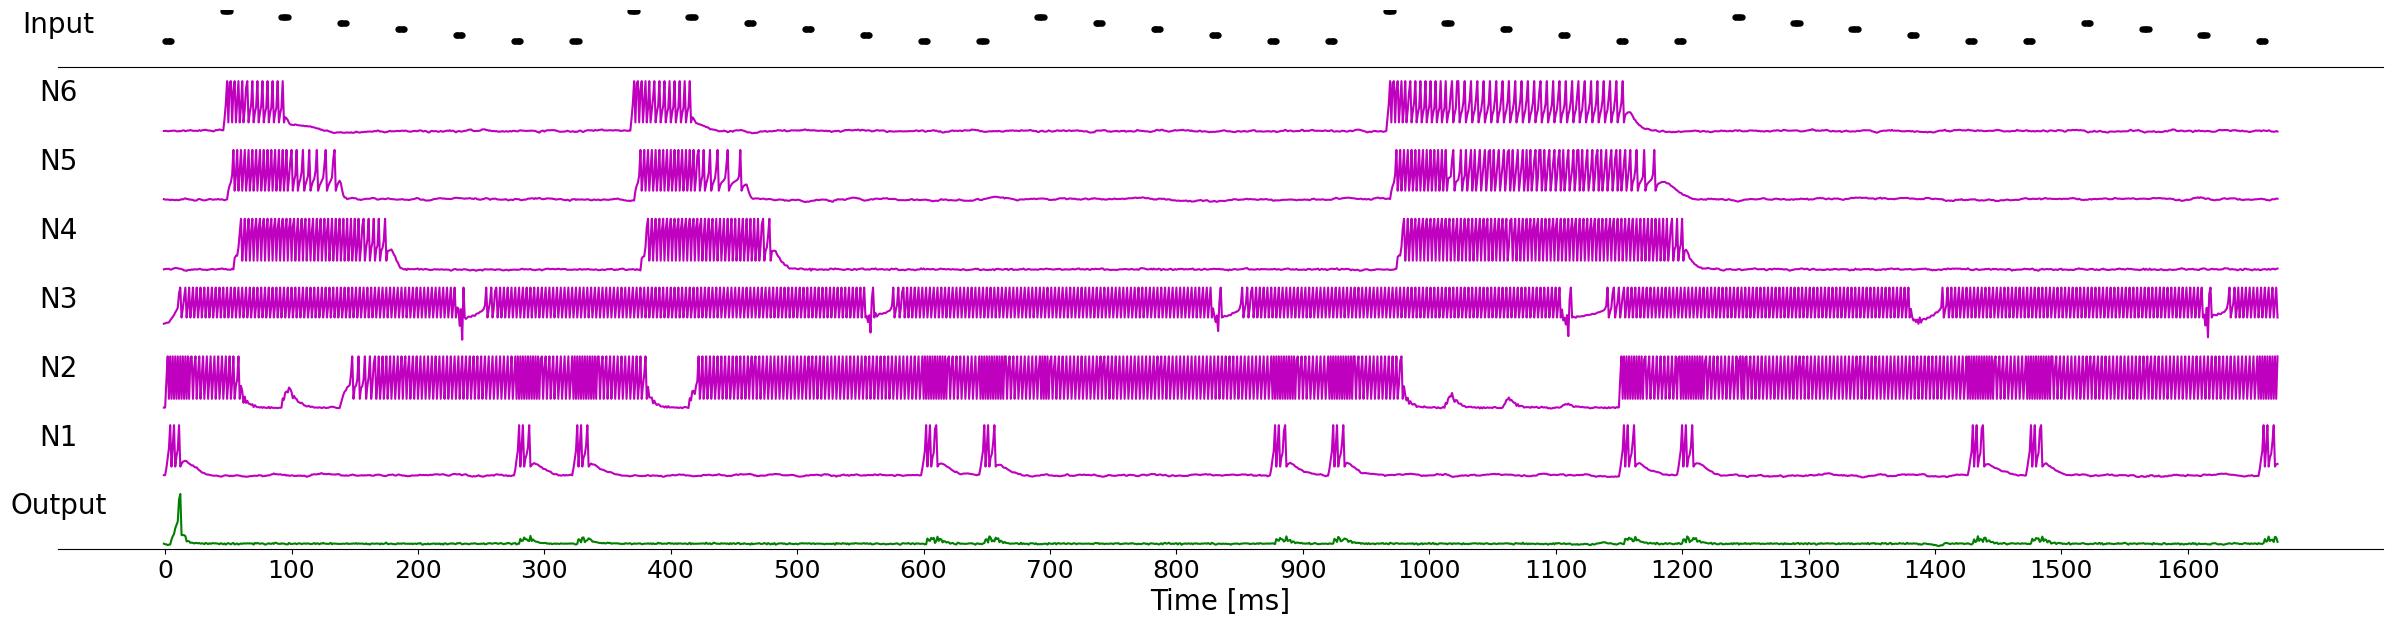

Successfully plotted: network_activity_Top_6_FABCDEFFABCDEFFBCDEFFACDEFFBCDEFFCDEF.txt
Processing: network_activity_Top_6_no_N6_loop_FABCDEFFBCDEFFCDEFFDEF.txt


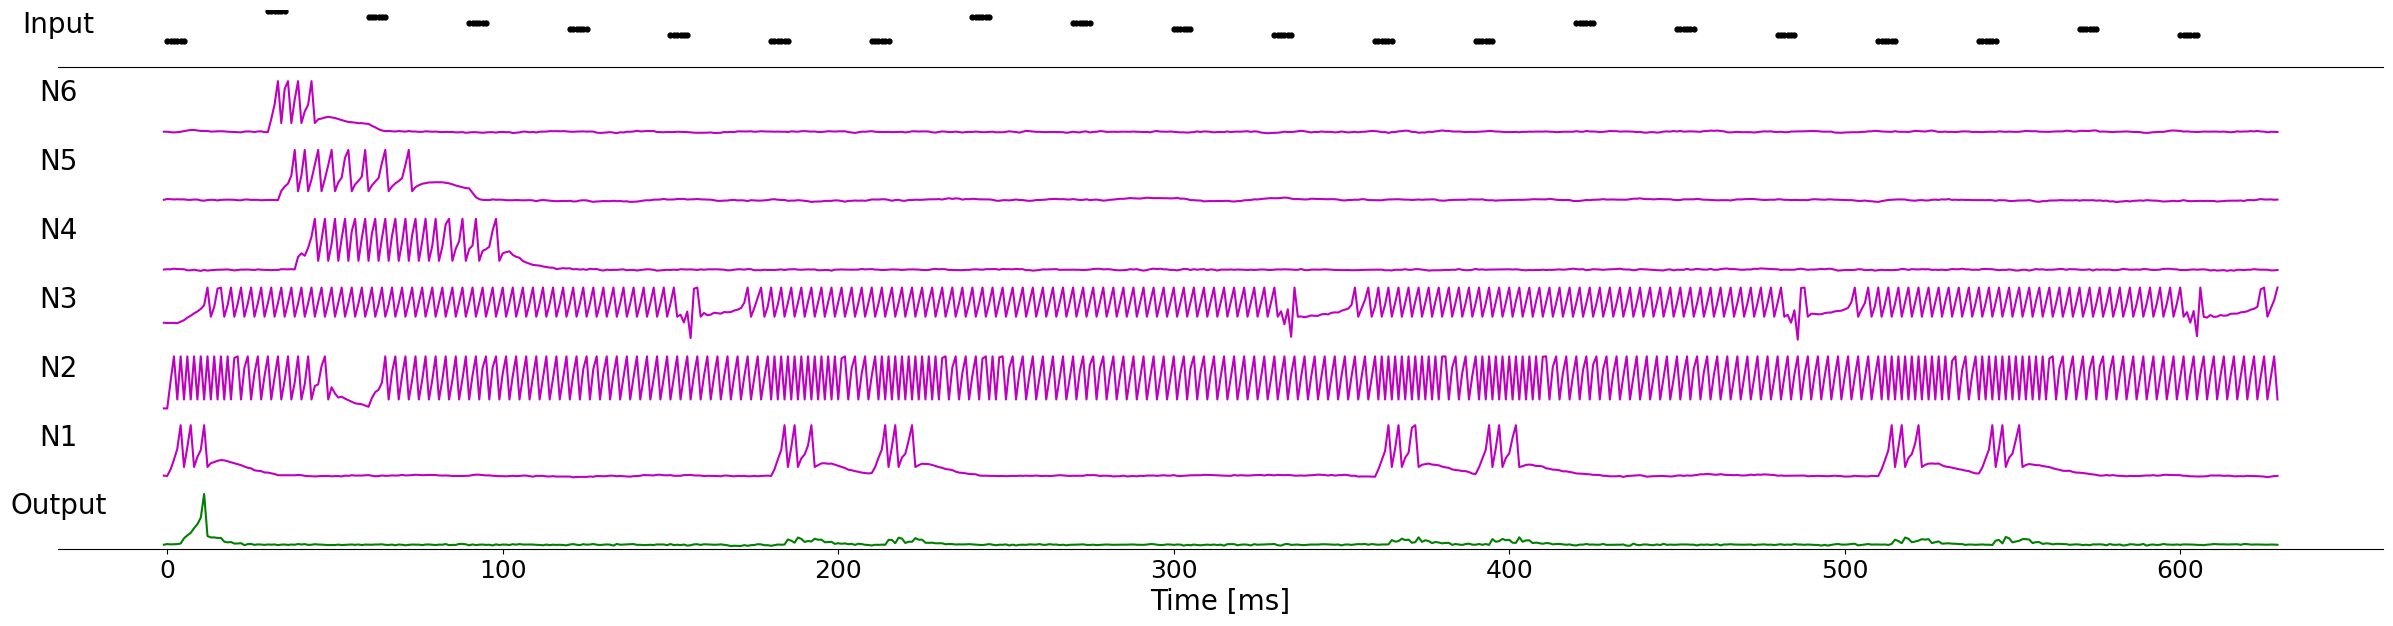

Successfully plotted: network_activity_Top_6_no_N6_loop_FABCDEFFBCDEFFCDEFFDEF.txt
Processing: network_activity_Top_6_no_N5_loop_FABCDEFFBCDEFFACDEF.txt


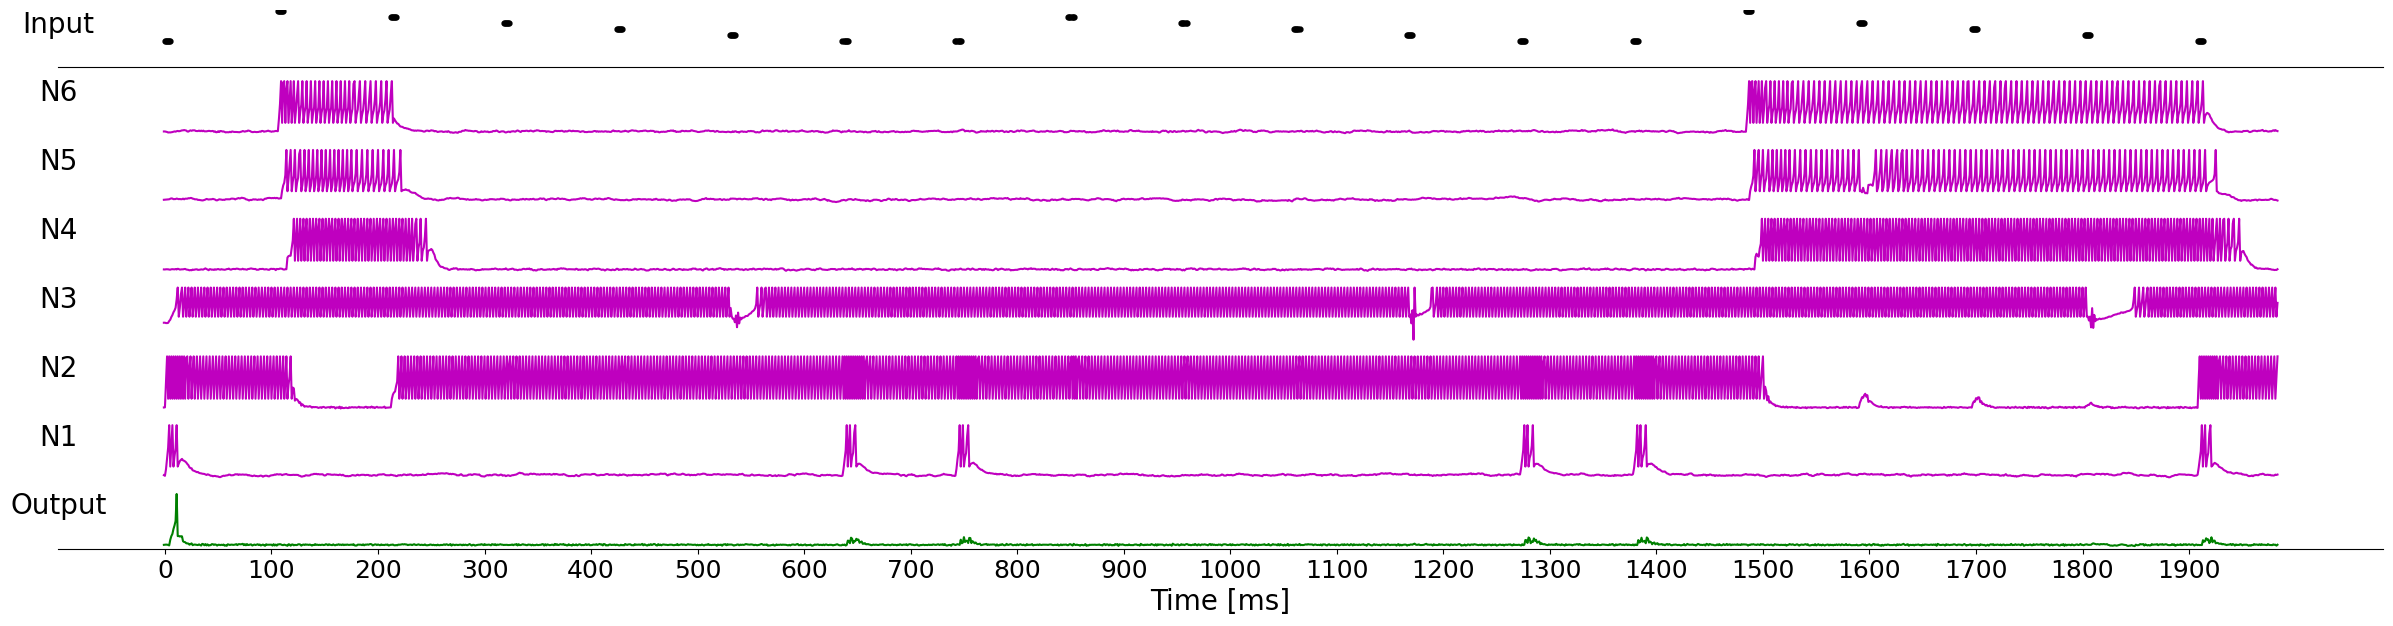

Successfully plotted: network_activity_Top_6_no_N5_loop_FABCDEFFBCDEFFACDEF.txt
Processing: network_activity_Top_6_no_N6_loop_FABCDEFFBCDEFFACDEF.txt


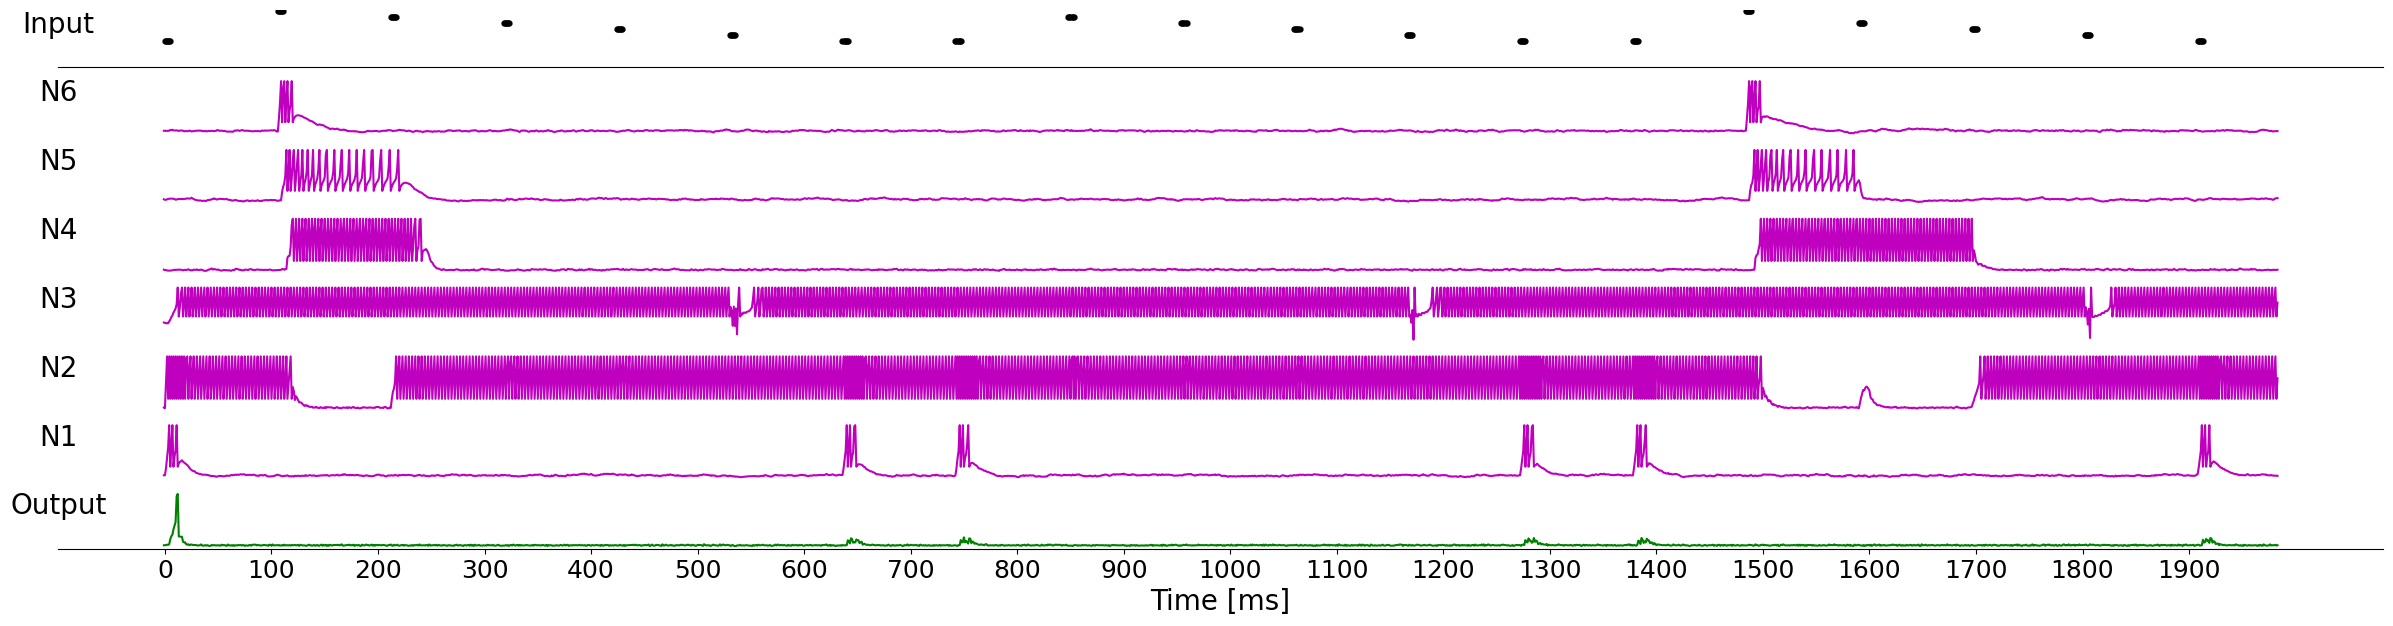

Successfully plotted: network_activity_Top_6_no_N6_loop_FABCDEFFBCDEFFACDEF.txt
Processing: network_activity_Top_6_FACDEFFACDEFFACDEFFACDEF.txt


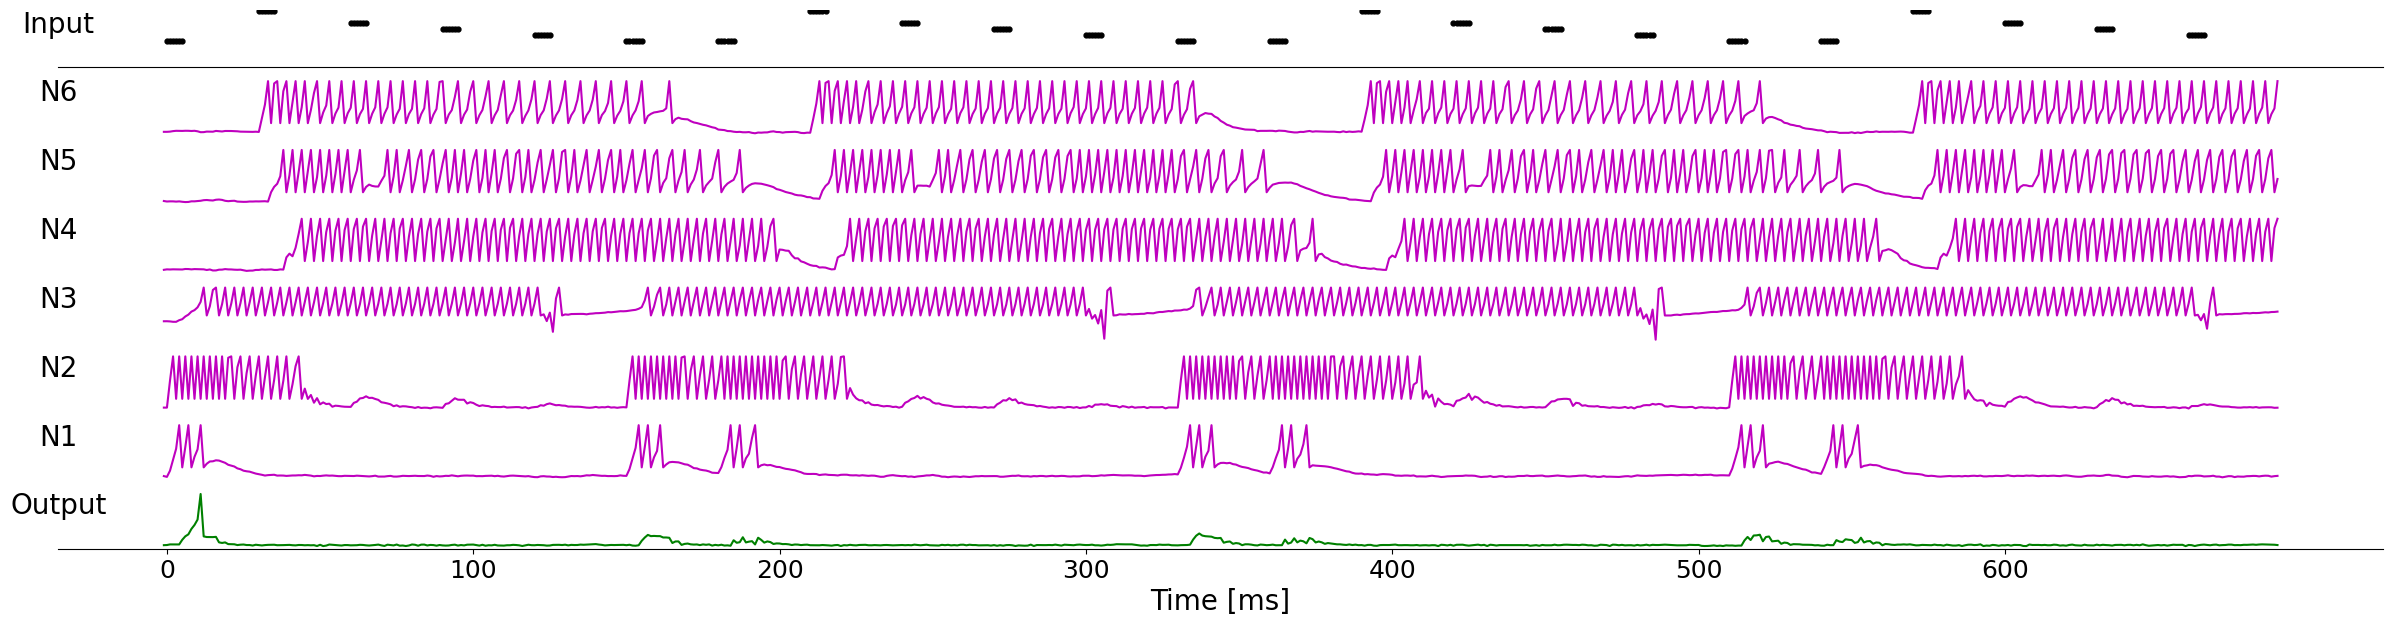

Successfully plotted: network_activity_Top_6_FACDEFFACDEFFACDEFFACDEF.txt
Processing: network_activity_Top_6_FABCDEFFACDEFFADEFAEFAF.txt


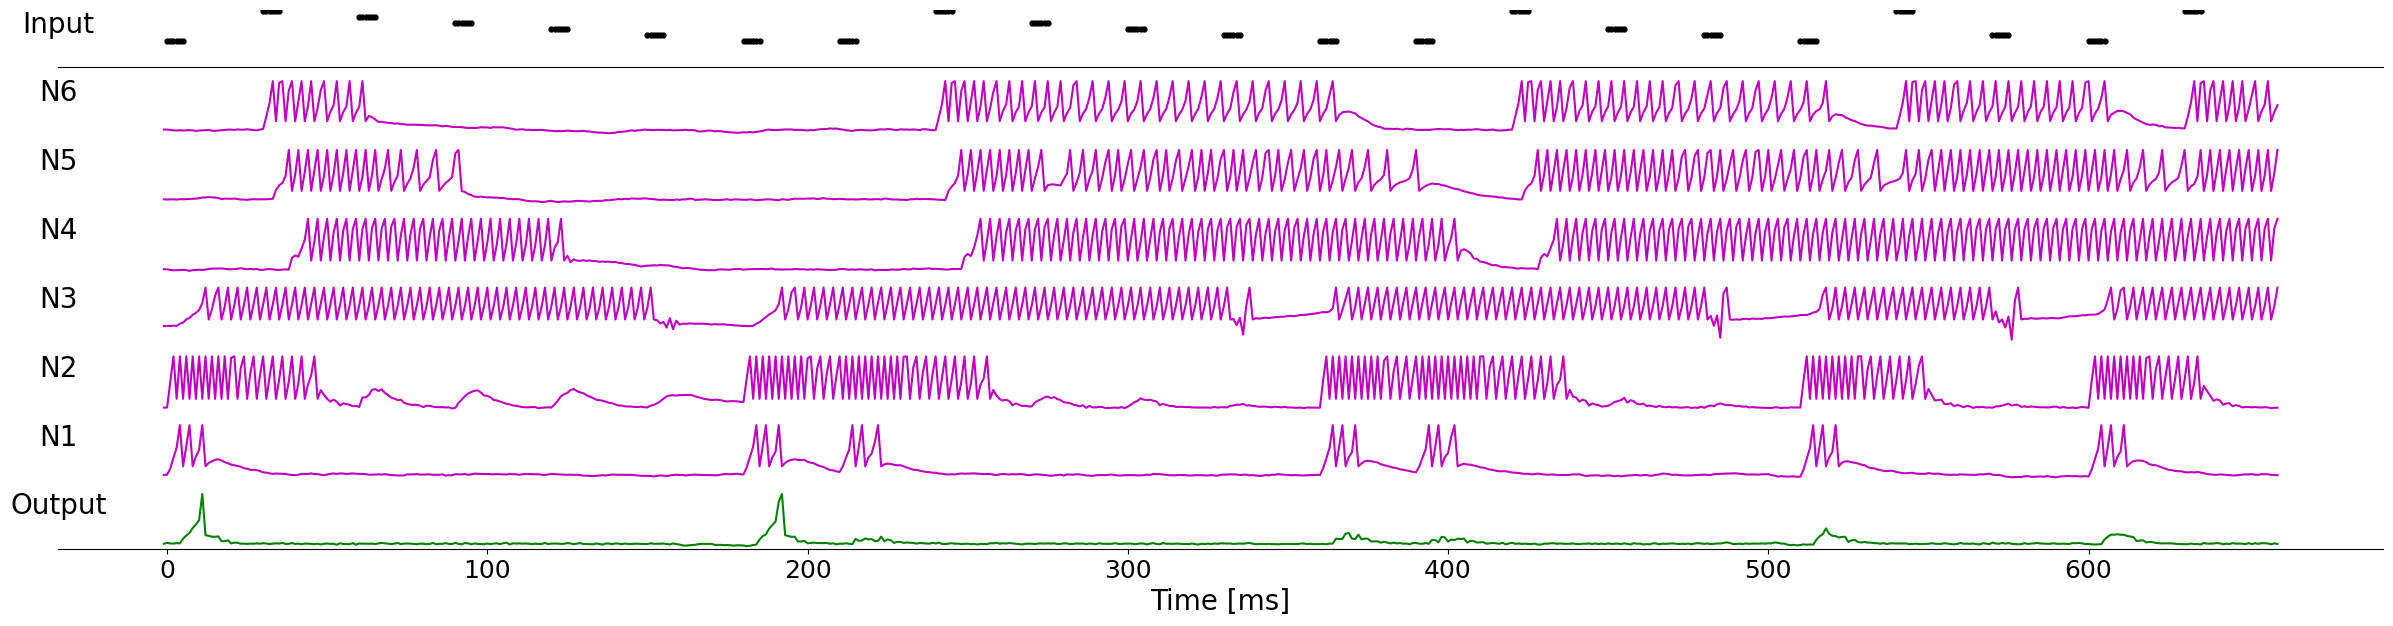

Successfully plotted: network_activity_Top_6_FABCDEFFACDEFFADEFAEFAF.txt
In the Directory: /Users/my19aac/Desktop/Evosnn2/6_loops_test/test_all_sequences
In the Directory: /Users/my19aac/Desktop/Evosnn2/6_loops_test/evolution
In the Directory: /Users/my19aac/Desktop/Evosnn2/6_loops_test/evolution/Top_6
In the Directory: /Users/my19aac/Desktop/Evosnn2/6_loops_test/evolution/Top_6/individuals
In the Directory: /Users/my19aac/Desktop/Evosnn2/6_loops_test/evolution/Top_6/individuals/run_low_fitness
In the Directory: /Users/my19aac/Desktop/Evosnn2/6_loops_test/evolution/Top_6/individuals/run_converged
In the Directory: /Users/my19aac/Desktop/Evosnn2/6_loops_test/.ipynb_checkpoints


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

rootDir = os.getcwd()
for dirName, subdirList, fileList in os.walk(rootDir):
    print(f"In the Directory: {dirName}")
    for fname in fileList:
        if fname.startswith('network_activity_T') and (fname.endswith('.txt') or fname.endswith('.dat')):
            filepath = os.path.join(dirName, fname)
            try:
                print(f"Processing: {fname}")
                x = np.loadtxt(filepath, 'float')
                plot(x, fname, num_inputs=6, num_interneurons=6)
                print(f"Successfully plotted: {fname}")
            except Exception as e:
                print(f"Error processing {fname}: {e}")

In [14]:
fname = 'network_activity_Top_3_5_splitloops_AABBBAABCCCABCAAA.txt'

In [13]:
def plot(x, fname):
    # Determine plotting window based on data length
    if len(x) > 605:
        clockVal = len(x) - 30
        skipVal = 0
        gWidth = 30
    else:
        clockVal = len(x) - 2
        skipVal = 0
        gWidth = 20
    
    # Create figure with 5 subplots (1 for inputs, 3 for neurons, 1 for output)
    fig, (ax_input, ax_n0, ax_n1, ax_n2, ax_output) = plt.subplots(
        5, 1, sharex=False, sharey=False, figsize=(gWidth, 7)
    )
    
    # Extract data columns
    clock = x[:, 0][skipVal:clockVal]
    A = x[:, 2][skipVal:clockVal]
    B = x[:, 3][skipVal:clockVal]
    C = x[:, 4][skipVal:clockVal]
    N3 = x[:, 5][skipVal:clockVal]
    N2 = x[:, 6][skipVal:clockVal]
    N1 = x[:, 7][skipVal:clockVal]
    output = x[:, 1][skipVal:clockVal]
    
    # Styling parameters
    padVal = 0
    fSize = 20
    lwid = 3
    siz = 7
    
    # Plot inputs (A, B, C) as dots
    ax_input.plot(clock, A, 'k.', linewidth=lwid, markersize=siz)
    ax_input.plot(clock, B, 'k.', linewidth=lwid, markersize=siz)
    ax_input.plot(clock, C, 'k.', linewidth=lwid, markersize=siz)
    ax_input.set_ylabel('Input', rotation=0, fontsize=fSize, labelpad=padVal)
    ax_input.spines['top'].set_visible(False)
    ax_input.spines['right'].set_visible(False)
    ax_input.spines['left'].set_visible(False)
    ax_input.get_yaxis().set_ticks([])
    ax_input.get_xaxis().set_ticks([])
    
    # Plot N0
    ax_n0.plot(clock, N3, 'm-')
    ax_n0.set_ylabel('N3', rotation=0, fontsize=fSize, labelpad=padVal)
    ax_n0.spines['top'].set_visible(False)
    ax_n0.spines['right'].set_visible(False)
    ax_n0.spines['left'].set_visible(False)
    ax_n0.spines['bottom'].set_visible(False)
    ax_n0.get_yaxis().set_ticks([])
    ax_n0.get_xaxis().set_ticks([])
    
    # Plot N1
    ax_n1.plot(clock, N2, 'm-')
    ax_n1.set_ylabel('N2', rotation=0, fontsize=fSize, labelpad=padVal)
    ax_n1.spines['top'].set_visible(False)
    ax_n1.spines['right'].set_visible(False)
    ax_n1.spines['left'].set_visible(False)
    ax_n1.spines['bottom'].set_visible(False)
    ax_n1.get_yaxis().set_ticks([])
    ax_n1.get_xaxis().set_ticks([])
    
    # Plot N2
    ax_n2.plot(clock, N1, 'm-')
    ax_n2.set_ylabel('N1', rotation=0, fontsize=fSize, labelpad=padVal)
    ax_n2.spines['top'].set_visible(False)
    ax_n2.spines['right'].set_visible(False)
    ax_n2.spines['left'].set_visible(False)
    ax_n2.spines['bottom'].set_visible(False)
    ax_n2.get_yaxis().set_ticks([])
    ax_n2.get_xaxis().set_ticks([])
    
    # Plot output
    ax_output.plot(clock, output, 'g-')
    ax_output.set_ylabel('Output', rotation=0, fontsize=fSize, labelpad=padVal)
    ax_output.set_xlabel('Time [ms]', fontsize=fSize)
    ax_output.spines['top'].set_visible(False)
    ax_output.spines['right'].set_visible(False)
    ax_output.spines['left'].set_visible(False)
    ax_output.get_yaxis().set_ticks([])
    ax_output.set_xticks(np.arange(0, len(clock) + 1, 100))
    
    # Set tick label sizes
    matplotlib.rc('xtick', labelsize=18)
    matplotlib.rc('ytick', labelsize=18)
    
    # Set y-axis limits for input plot
    miny = -94
    maxy = 3
    ax_input.set_ylim([miny, maxy])
    
    # Save and display
    plt.savefig(fname + '.png', bbox_inches='tight', dpi=120)
    plt.show()
    plt.close()
    
    return

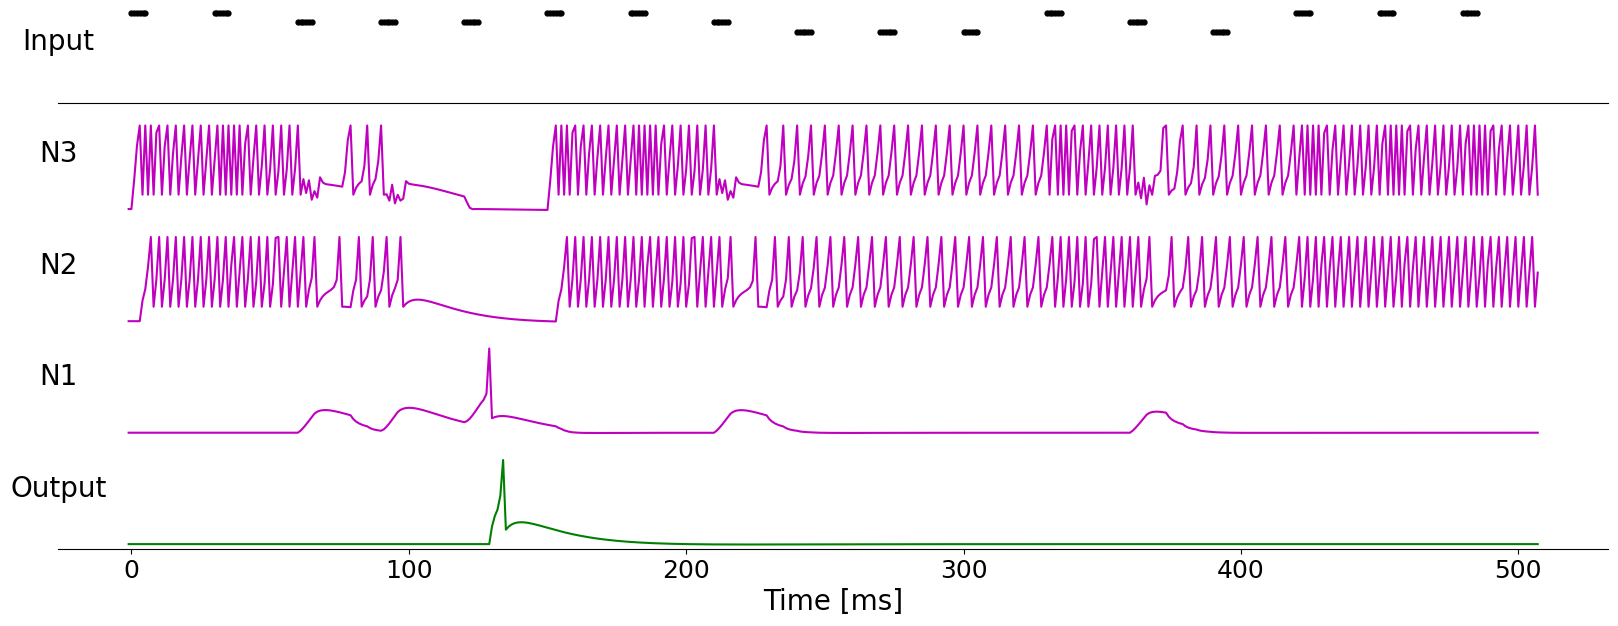

In [15]:
x = np.loadtxt(fname, 'float')
plot(x, fname)

In [55]:
fname = 'network_activity_Top_3_5_splitloops_evo_AAAABBBBBABCABCABCCCCAAA.txt'

In [56]:
x = np.loadtxt(fname, 'float')

In [57]:
x.shape

(721, 10)

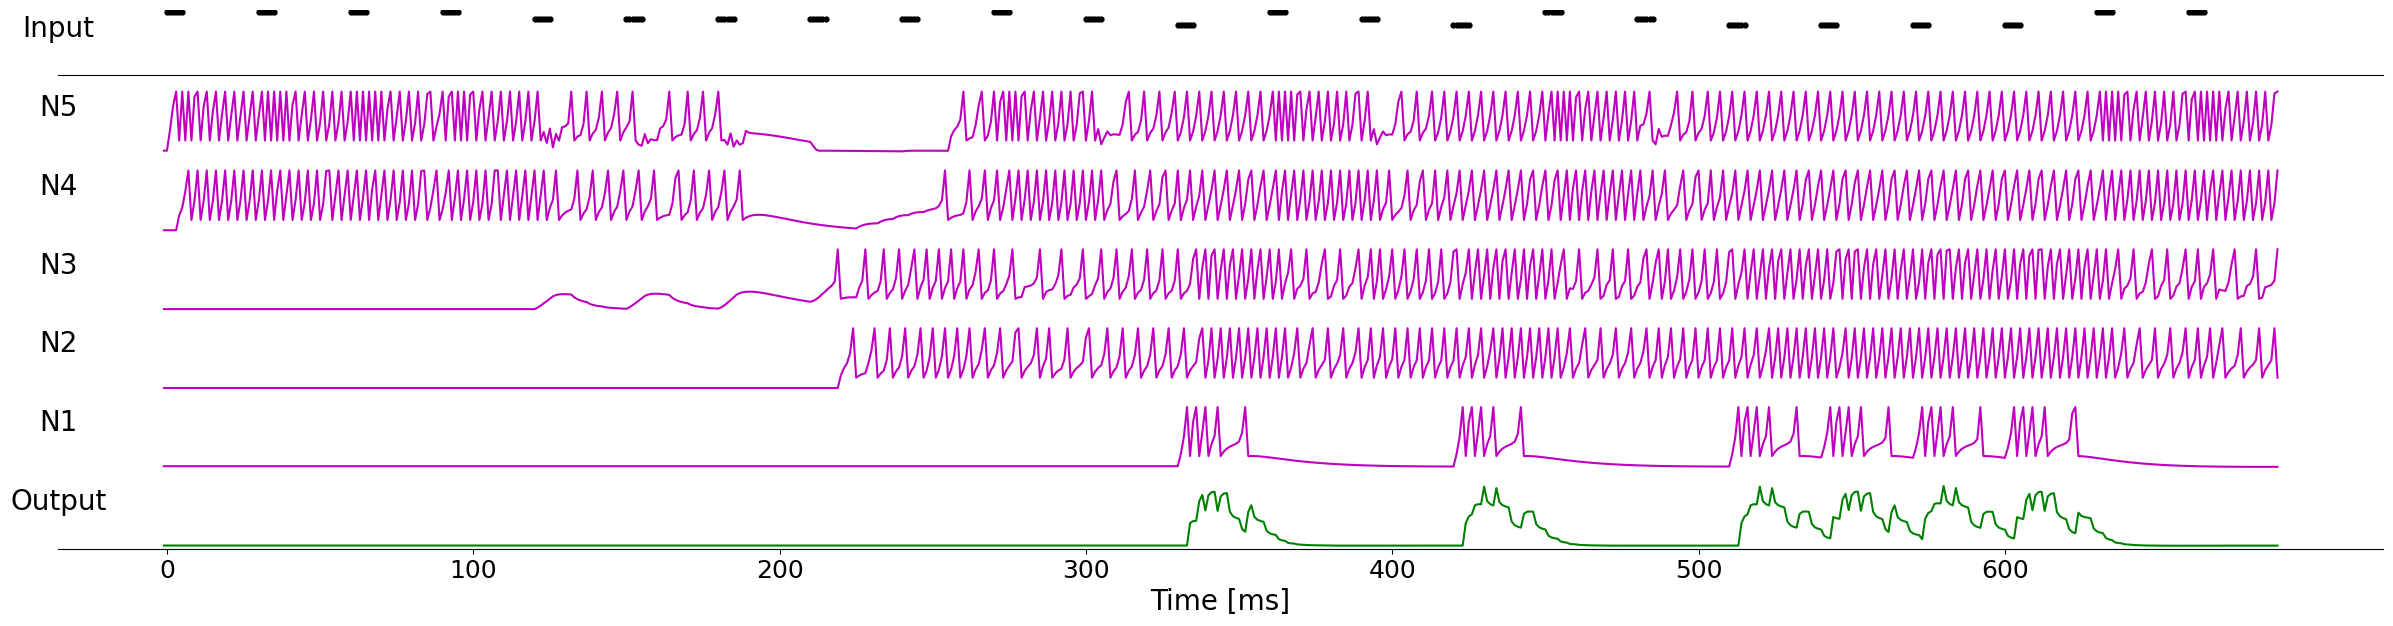

In [58]:

plot(x, fname,  num_inputs=3, num_interneurons=5)